# Laboratorio 7 — Spark MLlib
**CC3066 Data Science — Universidad del Valle de Guatemala — Semestre II 2026**

Análisis de salarios de personas asalariadas con la **Encuesta Nacional de Empleo e Ingresos Continua (ENEIC)** del INE.

- **Desarrollo / entrenamiento:** trimestres I–IV de 2025.
- **Prueba final:** trimestre I de 2026.

Todo el procesamiento analítico se realiza con **PySpark 3.5 (API de DataFrames / `pyspark.ml`)**. Los archivos Excel se leen con `openpyxl` (Spark no tiene lector nativo de Excel), se convierten a DataFrames de Spark con esquema explícito y se guardan en Parquet. A pandas sólo se transfieren tablas agregadas o muestras (≤ 10,000 registros) para graficar.

**Contenido:** secciones 1–4 (análisis exploratorio y segmentación) y 5–8 (modelado supervisado: regresión lineal, Random Forest, evaluación en 2026 y análisis de errores).

**Ejecución:** el notebook corre de principio a fin sin pasos manuales. Si los Excel no están en `data/raw/`, se descargan automáticamente del sitio del INE. Ver `README.md` para levantar el ambiente con Docker.

```
data/raw/        <- archivos .xlsx del INE (se descargan si faltan; no versionados)
data/parquet/    <- salidas Parquet generadas por este notebook
modelos/         <- pipelines de MLlib guardados
```

In [1]:
import os, json, math, glob, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import openpyxl

from pyspark.sql import SparkSession, functions as F, types as T
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.stat import Correlation
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator, RegressionEvaluator
from pyspark.ml import Pipeline, PipelineModel
from pyspark.ml.feature import StringIndexer, OneHotEncoder
from pyspark.ml.regression import LinearRegression, RandomForestRegressor

%matplotlib inline
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid")
SEED = 42

spark = (SparkSession.builder
         .appName("Lab7-ENEIC")
         .master("local[*]")
         .config("spark.driver.memory", "6g")
         .config("spark.sql.shuffle.partitions", "16")
         .config("spark.ui.showConsoleProgress", "false")
         .getOrCreate())
spark.sparkContext.setLogLevel("ERROR")
print("Spark", spark.version)

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/09/24 23:47:39 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark 3.5.1


---
# 1. Carga, armonización y calidad de datos

## 1.1 Archivos y columnas requeridas

Cada archivo se identifica por su **procedencia** (no por la columna `TRIMESTRE`). Se crean `archivo_origen`, `periodo_archivo`, `anio_archivo` y `trimestre_calendario` a partir de esta tabla.

In [2]:
RAW_DIR = "data/raw"
PQ_DIR = "data/parquet"
os.makedirs(PQ_DIR, exist_ok=True)

ARCHIVOS = [
    # archivo, periodo_archivo, anio_archivo, trimestre_calendario, uso
    ("Personas_ENEIC_T1_2025.xlsx",                 "2025T1", 2025, 1, "train"),
    ("Personas-ENEIC-T2-2025.xlsx",                 "2025T2", 2025, 2, "train"),
    ("Base-de-datos-Personas-ENEIC-III-2025.xlsx",  "2025T3", 2025, 3, "train"),
    ("Base-de-datos-Personas-ENEIC-IV-2025.xlsx",   "2025T4", 2025, 4, "validación"),
    ("Base-de-datos-Personas-ENEIC-I-2026.xlsx",    "2026T1", 2026, 1, "test"),
]

# Fuente oficial: https://www.ine.gob.gt/encuesta-nacional-de-empleo-e-ingresos/
URLS_INE = {
    "Personas_ENEIC_T1_2025.xlsx": "https://www.ine.gob.gt/wp-content/uploads/2026/01/Personas_ENEIC_T1_2025.xlsx",
    "Personas-ENEIC-T2-2025.xlsx": "https://www.ine.gob.gt/wp-content/uploads/2026/01/Personas-ENEIC-T2-2025.xlsx",
    "Base-de-datos-Personas-ENEIC-III-2025.xlsx": "https://www.ine.gob.gt/wp-content/uploads/2026/05/Base-de-datos-Personas-ENEIC-III-2025.xlsx",
    "Base-de-datos-Personas-ENEIC-IV-2025.xlsx": "https://www.ine.gob.gt/wp-content/uploads/2026/06/Base-de-datos-Personas-ENEIC-IV-2025.xlsx",
    "Base-de-datos-Personas-ENEIC-I-2026.xlsx": "https://www.ine.gob.gt/wp-content/uploads/2026/09/Base-de-datos-Personas-ENEIC-I-2026.xlsx",
    "Diccionario-Personas-ENEIC-I-2026.xlsx": "https://www.ine.gob.gt/wp-content/uploads/2026/09/Diccionario-Personas-ENEIC-I-2026.xlsx",
}

import urllib.request
os.makedirs(RAW_DIR, exist_ok=True)
for nombre, url in URLS_INE.items():
    ruta = f"{RAW_DIR}/{nombre}"
    if not os.path.exists(ruta):
        print("Descargando", nombre, "...")
        req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
        with urllib.request.urlopen(req) as r, open(ruta + ".part", "wb") as f:
            f.write(r.read())
        os.replace(ruta + ".part", ruta)
print("Archivos en data/raw:", sorted(os.listdir(RAW_DIR)))

# Columnas originales requeridas
COLS_ORIG = ["ANIO", "TRIMESTRE", "DOMINIO", "NUM_HOGAR", "NUM_PERSONA", "FACTOR",
             "OCUPADOS", "P02A03", "P05C07A", "P05C07B", "P05H01A",
             "P03A03A", "P05C16", "P05D01"]

Archivos en data/raw: ['Base-de-datos-Personas-ENEIC-I-2026.xlsx', 'Base-de-datos-Personas-ENEIC-III-2025.xlsx', 'Base-de-datos-Personas-ENEIC-IV-2025.xlsx', 'Diccionario-Personas-ENEIC-I-2026.xlsx', 'Personas-ENEIC-T2-2025.xlsx', 'Personas_ENEIC_T1_2025.xlsx']


## 1.2 Lectura individual de cada Excel → Parquet crudo

Cada archivo se procesa **por separado** para controlar memoria:

1. `openpyxl` en modo `read_only` recorre las filas y extrae **sólo** las 14 columnas requeridas, localizándolas **por nombre** en el encabezado (no por posición).
2. Como un mismo código puede llegar como número (`2`, `2.0`) o como texto (`'2'`, `' 2 '`), todo valor se normaliza a una **cadena canónica** (`2.0 → "2"`, espacios recortados, vacío → nulo). Así el DataFrame de Spark se crea con un esquema explícito homogéneo (`StringType`) y la conversión numérica se hace después, de forma idéntica para los cinco archivos.
3. El resultado se guarda en `data/parquet/crudo/<periodo>` (si ya existe, se reutiliza para no releer el Excel).

In [3]:
def normalizar(v):
    # Representación canónica en texto de un valor de celda
    if v is None:
        return None
    if isinstance(v, bool):
        return str(int(v))
    if isinstance(v, int):
        return str(v)
    if isinstance(v, float):
        if math.isfinite(v) and v.is_integer():
            return str(int(v))
        return repr(v)          # conserva 'nan' / 'inf' para poder detectarlos después
    s = str(v).strip()
    return s if s != "" else None

ESQUEMA_CRUDO = T.StructType([T.StructField(c, T.StringType(), True) for c in COLS_ORIG])

def excel_a_parquet(archivo, periodo):
    destino = f"{PQ_DIR}/crudo/{periodo}"
    meta_path = f"{PQ_DIR}/crudo/{periodo}_meta.json"
    if os.path.exists(destino) and os.path.exists(meta_path):
        with open(meta_path) as f:
            return json.load(f)
    t0 = time.time()
    wb = openpyxl.load_workbook(f"{RAW_DIR}/{archivo}", read_only=True, data_only=True)
    ws = wb[wb.sheetnames[0]]
    filas = ws.iter_rows(values_only=True)
    encabezado = [str(h).strip().upper() if h is not None else "" for h in next(filas)]
    idx = {c: encabezado.index(c) for c in COLS_ORIG}
    datos = []
    for fila in filas:
        if fila is None or all(v is None for v in fila):
            continue            # filas completamente vacías al final de la hoja
        datos.append(tuple(normalizar(fila[idx[c]]) for c in COLS_ORIG))
    wb.close()
    sdf = spark.createDataFrame(datos, schema=ESQUEMA_CRUDO)
    sdf.write.mode("overwrite").parquet(destino)
    meta = {"archivo": archivo, "hoja": ws.title, "n_columnas": len([h for h in encabezado if h]),
            "n_filas": len(datos), "posiciones": {c: idx[c] + 1 for c in COLS_ORIG}}
    with open(meta_path, "w") as f:
        json.dump(meta, f)
    print(f"{periodo}: {len(datos):,} filas leídas en {time.time()-t0:.0f}s")
    return meta

META = {p: excel_a_parquet(a, p) for a, p, *_ in ARCHIVOS}
pd.DataFrame({p: {"hoja": m["hoja"], "columnas originales": m["n_columnas"], "registros originales": m["n_filas"]}
              for p, m in META.items()}).T

,hoja,columnas originales,registros originales
2025T1,Personas_ENEIC_T1_2025,270,51588
2025T2,Personas ENEIC T2-2025,270,51167
2025T3,Personas ENEIC T3-2025,270,51583
2025T4,Base de datos Personas ENEIC IV,302,49338
2026T1,Personas_ENEIC_T1-2026,270,49843


Los conteos coinciden con los de la tabla del enunciado (51,588 / 51,167 / 51,583 / 49,338 / 49,843) y el archivo IV‑2025 tiene 302 columnas frente a 270 de los demás.

### ¿Por qué IV‑2025 no puede apilarse por posición?
La siguiente tabla muestra la **posición (1‑based)** de cada columna requerida dentro de su archivo:

In [4]:
posiciones = pd.DataFrame({p: m["posiciones"] for p, m in META.items()})
posiciones["¿misma posición en todos?"] = posiciones.nunique(axis=1).eq(1)
posiciones

,2025T1,2025T2,2025T3,2025T4,2026T1,¿misma posición en todos?
ANIO,1,1,1,1,1,True
TRIMESTRE,2,2,2,2,2,True
DOMINIO,3,3,3,3,3,True
NUM_HOGAR,4,4,4,4,4,True
NUM_PERSONA,7,7,7,7,7,True
FACTOR,5,5,5,5,5,True
OCUPADOS,266,266,266,298,266,False
P02A03,13,13,13,9,13,False
P05C07A,68,68,68,61,68,False
P05C07B,69,69,69,62,69,False


IV‑2025 tiene **32 columnas adicionales** y un orden distinto: por ejemplo la edad (`P02A03`) está en la columna 9 en lugar de la 13, y `OCUPADOS` en la 298 en lugar de la 266. Un `union()` posicional pegaría la edad de un archivo con otra variable del otro (p. ej. un código de residencia), produciendo datos silenciosamente corruptos (o fallaría por diferente número de columnas). Por eso se selecciona cada variable **por nombre** y se une con **`unionByName`**, que empareja columnas por su nombre y no por su posición.

## 1.3 Homologación de tipos e identificación del período

- Variables numéricas continuas (`P02A03`, `P05C07A`, `P05C07B`, `P05H01A`, `P05D01`, `FACTOR`) → `double`. Un texto no numérico queda como nulo.
- Códigos (`DOMINIO`, `OCUPADOS`, `P05C16`, `P03A03A`, `ANIO`, `TRIMESTRE`) → `int` **sólo si** el valor es un número entero; de lo contrario, nulo.
- Identificadores `NUM_HOGAR`, `NUM_PERSONA` → `long`.
- `TRIMESTRE` se **conserva sin modificar**; el período se toma del archivo de procedencia.

In [5]:
def a_double(c):
    return F.col(c).cast("double")

def a_codigo(c, tipo="int"):
    d = F.col(c).cast("double")
    return F.when(d.isNotNull() & ~F.isnan(d) & (d == F.floor(d)), d.cast(tipo))

def cargar_homologado(archivo, periodo, anio, trim, uso):
    return (spark.read.parquet(f"{PQ_DIR}/crudo/{periodo}")
            .select(
                F.lit(archivo).alias("archivo_origen"),
                F.lit(periodo).alias("periodo_archivo"),
                F.lit(anio).cast("int").alias("anio_archivo"),
                F.lit(trim).cast("int").alias("trimestre_calendario"),
                a_codigo("ANIO").alias("ANIO"),
                a_codigo("TRIMESTRE").alias("TRIMESTRE"),
                a_codigo("NUM_HOGAR", "long").alias("NUM_HOGAR"),
                a_codigo("NUM_PERSONA", "long").alias("NUM_PERSONA"),
                a_double("FACTOR").alias("FACTOR"),
                a_codigo("DOMINIO").alias("dominio_cod"),
                a_codigo("OCUPADOS").alias("ocupado"),
                a_double("P02A03").alias("edad"),
                a_double("P05C07A").alias("antiguedad_anios"),
                a_double("P05C07B").alias("antiguedad_meses"),
                a_double("P05H01A").alias("horas_semanales"),
                a_codigo("P03A03A").alias("nivel_educativo_cod"),
                a_codigo("P05C16").alias("categoria_ocupacional_cod"),
                a_double("P05D01").alias("salario_mensual"),
            ))

dfs = {p: cargar_homologado(a, p, y, t, u) for a, p, y, t, u in ARCHIVOS}

# Unión de los cuatro archivos de 2025 por NOMBRE de columna
from functools import reduce
df25_raw = reduce(lambda a, b: a.unionByName(b), [dfs[p] for p in ["2025T1", "2025T2", "2025T3", "2025T4"]])
df26_raw = dfs["2026T1"]
df_all_raw = df25_raw.unionByName(df26_raw).persist()

print(f"2025 (unión): {df25_raw.count():,} registros | 2026: {df26_raw.count():,} registros")
df_all_raw.printSchema()

2025 (unión): 203,676 registros | 2026: 49,843 registros
root
 |-- archivo_origen: string (nullable = false)
 |-- periodo_archivo: string (nullable = false)
 |-- anio_archivo: integer (nullable = false)
 |-- trimestre_calendario: integer (nullable = false)
 |-- ANIO: integer (nullable = true)
 |-- TRIMESTRE: integer (nullable = true)
 |-- NUM_HOGAR: long (nullable = true)
 |-- NUM_PERSONA: long (nullable = true)
 |-- FACTOR: double (nullable = true)
 |-- dominio_cod: integer (nullable = true)
 |-- ocupado: integer (nullable = true)
 |-- edad: double (nullable = true)
 |-- antiguedad_anios: double (nullable = true)
 |-- antiguedad_meses: double (nullable = true)
 |-- horas_semanales: double (nullable = true)
 |-- nivel_educativo_cod: integer (nullable = true)
 |-- categoria_ocupacional_cod: integer (nullable = true)
 |-- salario_mensual: double (nullable = true)



**Esquema y cinco registros** de las columnas seleccionadas (unión 2025):

In [6]:
df25_raw.show(5, truncate=False)

+---------------------------+---------------+------------+--------------------+----+---------+---------+-----------+------+-----------+-------+----+----------------+----------------+---------------+-------------------+-------------------------+---------------+
|archivo_origen             |periodo_archivo|anio_archivo|trimestre_calendario|ANIO|TRIMESTRE|NUM_HOGAR|NUM_PERSONA|FACTOR|dominio_cod|ocupado|edad|antiguedad_anios|antiguedad_meses|horas_semanales|nivel_educativo_cod|categoria_ocupacional_cod|salario_mensual|
+---------------------------+---------------+------------+--------------------+----+---------+---------+-----------+------+-----------+-------+----+----------------+----------------+---------------+-------------------+-------------------------+---------------+
|Personas_ENEIC_T1_2025.xlsx|2025T1         |2025        |1                   |2025|2        |16033    |2          |356.0 |2          |1      |44.0|6.0             |0.0             |50.0           |5                  

### Valores originales de `TRIMESTRE` por archivo
Se verifica que la columna original no coincide con el trimestre calendario (y que en II‑2025 hay registros con `TRIMESTRE = 2`). Por eso **no** se resta 1: esa regla asignaría 175 registros de II‑2025 al primer trimestre y convertiría el 6 de I‑2026 en un inexistente "trimestre 5".

In [7]:
(df_all_raw.groupBy("periodo_archivo", "trimestre_calendario", "TRIMESTRE").count()
 .orderBy("periodo_archivo", "TRIMESTRE").toPandas())

,periodo_archivo,trimestre_calendario,TRIMESTRE,count
0,2025T1,1,2,51588
1,2025T2,2,2,175
2,2025T2,2,3,50992
3,2025T3,3,4,51583
4,2025T4,4,5,49338
5,2026T1,1,6,49843


## 1.4 Faltantes por variable **antes** de aplicar filtros

Se cuentan los nulos tras la homologación (incluye celdas vacías y valores no convertibles a número/código).

In [8]:
VARS_SEL = ["ANIO", "TRIMESTRE", "NUM_HOGAR", "NUM_PERSONA", "FACTOR", "dominio_cod", "ocupado", "edad",
            "antiguedad_anios", "antiguedad_meses", "horas_semanales", "nivel_educativo_cod",
            "categoria_ocupacional_cod", "salario_mensual"]

def tabla_faltantes(df, etiqueta):
    n = df.count()
    fila = df.select([F.sum(F.col(c).isNull().cast("int")).alias(c) for c in VARS_SEL]).first().asDict()
    return pd.DataFrame({f"{etiqueta} faltantes": fila,
                         f"{etiqueta} %": {k: round(100 * v / n, 2) for k, v in fila.items()}})

faltantes = pd.concat([tabla_faltantes(df25_raw, "2025"), tabla_faltantes(df26_raw, "2026")], axis=1)
faltantes

,2025 faltantes,2025 %,2026 faltantes,2026 %
ANIO,0,0.00,0,0.00
TRIMESTRE,0,0.00,0,0.00
NUM_HOGAR,0,0.00,0,0.00
NUM_PERSONA,0,0.00,0,0.00
FACTOR,0,0.00,0,0.00
dominio_cod,0,0.00,0,0.00
ocupado,115454,56.69,28109,56.40
edad,0,0.00,0,0.00
antiguedad_anios,115454,56.69,28109,56.40
antiguedad_meses,115454,56.69,28109,56.40


Para distinguir **faltantes estructurales** (la pregunta no corresponde) de **no respuesta**, se repite el conteo sólo entre personas de 15+ años, ocupadas y asalariadas (a quienes sí se les debía preguntar por salario, antigüedad y horas):

In [9]:
cond_aplica = (F.col("edad") >= 15) & (F.col("ocupado") == 1) & F.col("categoria_ocupacional_cod").isin(1, 2, 3, 4)
pd.concat([tabla_faltantes(df25_raw.filter(cond_aplica), "2025 asalariados"),
           tabla_faltantes(df26_raw.filter(cond_aplica), "2026 asalariados")], axis=1)

,2025 asalariados faltantes,2025 asalariados %,2026 asalariados faltantes,2026 asalariados %
ANIO,0,0.0,0,0.0
TRIMESTRE,0,0.0,0,0.0
NUM_HOGAR,0,0.0,0,0.0
NUM_PERSONA,0,0.0,0,0.0
FACTOR,0,0.0,0,0.0
dominio_cod,0,0.0,0,0.0
ocupado,0,0.0,0,0.0
edad,0,0.0,0,0.0
antiguedad_anios,0,0.0,0,0.0
antiguedad_meses,0,0.0,0,0.0


**Interpretación.** En la base completa, las variables laborales (`ocupado`, `categoria_ocupacional`, antigüedad, horas y sobre todo `salario_mensual`) tienen porcentajes de faltantes muy altos. Esto **no** es un problema de calidad: la ENEIC aplica *saltos de flujo*; a niños, inactivos, desocupados o trabajadores por cuenta propia simplemente no se les pregunta por un salario. Cuando la tabla se restringe a quienes sí debían responder (asalariados ocupados de 15+), los faltantes **caen a cero**: en estas bases no hay no respuesta registrada en las variables del análisis.

Nota sobre `OCUPADOS`: según el diccionario, la variable sólo toma el valor 1 (población ocupada). Su "faltante" no es una respuesta perdida: significa que la persona **no** está ocupada (es desocupada, inactiva o menor de edad). `nivel_educativo` falta para ≈ 13% de los registros, y **todos** ellos son niños menores de 7 años, a quienes no se les aplica la pregunta (faltante estructural).

### ¿Qué diferencia existe entre un dato ausente porque la pregunta no corresponde y una respuesta no registrada?
- **No corresponde (faltante estructural / por diseño):** el cuestionario excluye a la persona de la pregunta (p. ej. salario de un menor, de un inactivo o de un cuenta propia). El valor *no existe* conceptualmente; imputarlo no tiene sentido y la persona simplemente no pertenece a la población de análisis.
- **Respuesta no registrada (no respuesta):** la pregunta sí aplicaba, pero la persona no sabe, no quiso responder o hubo un error de captura. El valor existe pero es desconocido; puede introducir sesgo si la no respuesta está relacionada con el salario (p. ej. personas de ingresos altos que no revelan su sueldo). En este laboratorio esos registros se **excluyen y se contabilizan**, no se imputan.

## 1.5 Unicidad de la clave `periodo_archivo` + `NUM_HOGAR` + `NUM_PERSONA`

In [10]:
CLAVE = ["periodo_archivo", "NUM_HOGAR", "NUM_PERSONA"]
dup = df_all_raw.groupBy(CLAVE).count().filter("count > 1")
print("Claves nulas:", df_all_raw.filter(F.col("NUM_HOGAR").isNull() | F.col("NUM_PERSONA").isNull()).count())
print("Claves duplicadas (antes de filtros):", dup.count(),
      "| registros involucrados:", dup.agg(F.coalesce(F.sum("count"), F.lit(0))).first()[0])
dup.groupBy("periodo_archivo").agg(F.count("*").alias("claves_duplicadas"), F.sum("count").alias("registros")).toPandas()

Claves nulas: 0


Claves duplicadas (antes de filtros): 0 | registros involucrados: 0


,periodo_archivo,claves_duplicadas,registros


In [11]:
# Si hubiera claves repetidas: ¿son repeticiones exactas o registros en conflicto?
cols_contenido = [c for c in df_all_raw.columns if c not in CLAVE]
if dup.count() > 0:
    detalle = (df_all_raw.join(dup.select(CLAVE), CLAVE)
               .groupBy(CLAVE)
               .agg(F.count("*").alias("filas"),
                    F.countDistinct(F.to_json(F.struct(*cols_contenido))).alias("versiones_distintas")))
    resumen_dup = detalle.withColumn("tipo", F.when(F.col("versiones_distintas") == 1, "repetición exacta")
                                               .otherwise("registros en conflicto"))
    display(resumen_dup.groupBy("periodo_archivo", "tipo").count().toPandas())
    display(df_all_raw.join(dup.select(CLAVE).limit(3), CLAVE).orderBy(CLAVE).toPandas())
else:
    print("La combinación periodo_archivo + NUM_HOGAR + NUM_PERSONA es única en todos los archivos.")

La combinación periodo_archivo + NUM_HOGAR + NUM_PERSONA es única en todos los archivos.


### Unicidad entre períodos (diseño longitudinal)
La clave **sin** el período sí se repite: la ENEIC es un panel rotativo y el mismo hogar/persona puede observarse en varios trimestres.

In [12]:
visitas = (df25_raw.groupBy("NUM_HOGAR", "NUM_PERSONA")
           .agg(F.countDistinct("periodo_archivo").alias("trimestres_observado")))
visitas.groupBy("trimestres_observado").count().orderBy("trimestres_observado").toPandas()

,trimestres_observado,count
0,1,31273
1,2,27771
2,3,16279
3,4,17006


### ¿Por qué una persona observada en dos períodos no debe eliminarse como duplicado?
Porque **no es un duplicado**: son dos observaciones distintas de la misma persona en momentos diferentes, cada una con su propia edad, horas, antigüedad y salario de ese trimestre. La ENEIC es un diseño longitudinal con rotación, y cada trimestre es una muestra completa y válida por sí misma (con su propio `FACTOR`). Eliminar una de las visitas: (1) sesgaría las distribuciones de los trimestres afectados, (2) destruiría la información de cambio en el tiempo que da valor al panel y (3) rompería la representatividad de cada corte trimestral. Un duplicado sólo existe **dentro** de un mismo período (misma clave `periodo_archivo`, `NUM_HOGAR`, `NUM_PERSONA`). Como consecuencia, el número de filas acumuladas en 2025 **no** equivale al número de personas distintas.

## 1.6 Construcción de variables y filtros de la población analítica

**Categóricas** (validadas contra el diccionario de datos del INE; cualquier código ausente o no reconocido → `DESCONOCIDO`; el código educativo **0 = "Ninguno"** es un valor válido):

| Variable | Códigos válidos |
|---|---|
| `nivel_educativo` (`P03A03A`) | 0 Ninguno, 1 Preprimaria, 2 Primaria, 3 Básico, 4 Diversificado, 5 Superior, 6 Maestría, 7 Doctorado |
| `categoria_ocupacional` (`P05C16`) | 1 Gobierno, 2 Empresa privada, 3 Jornalero/peón, 4 Servicio doméstico (5–9 no asalariados) |
| `dominio` (`DOMINIO`) | 1 Urbano metropolitano, 2 Resto urbano, 3 Rural nacional |

**Antigüedad (años)** = `antiguedad_anios + antiguedad_meses / 12`.

**Filtros**, aplicados siempre **en el mismo orden** (un registro se contabiliza en el primer paso que no cumple):
1. Edad finita y ≥ 15.
2. Ocupado (`OCUPADOS = 1`).
3. Asalariado (`P05C16` ∈ {1, 2, 3, 4}).
4. Salario `P05D01` numérico, finito y > 0.
5. Años de antigüedad finitos y ≥ 0.
6. Meses de antigüedad enteros entre 0 y 11.
7. Antigüedad calculada ≤ edad.
8. Horas habituales > 0 y ≤ 168.

In [13]:
NIVEL_EDU = {0: "Ninguno", 1: "Preprimaria", 2: "Primaria", 3: "Básico", 4: "Diversificado",
             5: "Superior", 6: "Maestría", 7: "Doctorado"}
CAT_OCUP = {1: "Gobierno", 2: "Empresa privada", 3: "Jornalero/peón", 4: "Servicio doméstico"}
DOMINIO = {1: "Urbano metropolitano", 2: "Resto urbano", 3: "Rural nacional"}
ORDEN_EDU = list(NIVEL_EDU.values()) + ["DESCONOCIDO"]
ORDEN_CAT = list(CAT_OCUP.values()) + ["DESCONOCIDO"]
ORDEN_DOM = list(DOMINIO.values()) + ["DESCONOCIDO"]

def etiquetar(col, mapa):
    m = F.create_map(*[x for k, v in mapa.items() for x in (F.lit(k), F.lit(v))])
    return F.coalesce(m[F.col(col)], F.lit("DESCONOCIDO"))

def finito(c):
    c = F.col(c) if isinstance(c, str) else c
    return c.isNotNull() & ~F.isnan(c) & (c != float("inf")) & (c != float("-inf"))

def construir(df):
    return (df
            .withColumn("nivel_educativo", etiquetar("nivel_educativo_cod", NIVEL_EDU))
            .withColumn("categoria_ocupacional", etiquetar("categoria_ocupacional_cod", CAT_OCUP))
            .withColumn("dominio", etiquetar("dominio_cod", DOMINIO))
            .withColumn("antiguedad", F.col("antiguedad_anios") + F.col("antiguedad_meses") / 12))

PASOS = [
    ("1. Edad finita y >= 15",                finito("edad") & (F.col("edad") >= 15)),
    ("2. Ocupado (OCUPADOS = 1)",             F.col("ocupado") == 1),
    ("3. Asalariado (P05C16 en 1-4)",         F.col("categoria_ocupacional_cod").isin(1, 2, 3, 4)),
    ("4. Salario numérico, finito y > 0",     finito("salario_mensual") & (F.col("salario_mensual") > 0)),
    ("5. Años de antigüedad finitos y >= 0",  finito("antiguedad_anios") & (F.col("antiguedad_anios") >= 0)),
    ("6. Meses enteros entre 0 y 11",         finito("antiguedad_meses") & (F.col("antiguedad_meses") == F.floor("antiguedad_meses"))
                                              & F.col("antiguedad_meses").between(0, 11)),
    ("7. Antigüedad calculada <= edad",       F.col("antiguedad") <= F.col("edad")),
    ("8. Horas habituales > 0 y <= 168",      finito("horas_semanales") & (F.col("horas_semanales") > 0)
                                              & (F.col("horas_semanales") <= 168)),
]

def marcar_exclusion(df):
    # paso_excluido = número del PRIMER filtro que el registro no cumple (0 = cumple todos).
    # coalesce(cond, False) hace que un criterio no evaluable (nulo) cuente como no cumplido.
    expr = F.lit(0)
    for i in range(len(PASOS), 0, -1):
        expr = F.when(~F.coalesce(PASOS[i - 1][1], F.lit(False)), F.lit(i)).otherwise(expr)
    return construir(df).withColumn("paso_excluido", expr)

df_all_marcado = marcar_exclusion(df_all_raw).persist()

conteo = (df_all_marcado.groupBy("periodo_archivo").pivot("paso_excluido", list(range(len(PASOS) + 1)))
          .count().fillna(0).toPandas().set_index("periodo_archivo").sort_index())
conteo.columns = [int(c) for c in conteo.columns]
periodos = conteo.index.tolist()
tabla = pd.DataFrame(index=["Registros originales"] + [f"Excluidos en {n}" for n, _ in PASOS] + ["Registros finales"],
                     columns=periodos, dtype="int64")
tabla.loc["Registros originales"] = conteo.sum(axis=1)
for i, (n, _) in enumerate(PASOS, start=1):
    tabla.loc[f"Excluidos en {n}"] = conteo[i]
tabla.loc["Registros finales"] = conteo[0]
tabla["Total 2025"] = tabla[[p for p in periodos if p.startswith("2025")]].sum(axis=1)
tabla = tabla.astype("int64")
display(tabla)
print("% de registros conservados:")
(100 * tabla.loc["Registros finales"] / tabla.loc["Registros originales"]).round(2).to_frame("% conservado").T

,2025T1,2025T2,2025T3,2025T4,2026T1,Total 2025
Registros originales,51588,51167,51583,49338,49843,203676
Excluidos en 1. Edad finita y >= 15,16253,15882,15767,14984,14803,62886
Excluidos en 2. Ocupado (OCUPADOS = 1),13062,12942,13443,13121,13306,52568
Excluidos en 3. Asalariado (P05C16 en 1-4),8854,8851,8923,8569,8476,35197
"Excluidos en 4. Salario numérico, finito y > 0",0,0,0,0,0,0
Excluidos en 5. Años de antigüedad finitos y >= 0,0,0,0,0,0,0
Excluidos en 6. Meses enteros entre 0 y 11,0,0,0,0,0,0
Excluidos en 7. Antigüedad calculada <= edad,0,0,0,0,0,0
Excluidos en 8. Horas habituales > 0 y <= 168,0,0,0,0,0,0
Registros finales,13419,13492,13450,12664,13258,53025


% de registros conservados:


,2025T1,2025T2,2025T3,2025T4,2026T1,Total 2025
% conservado,26.01,26.37,26.07,25.67,26.6,26.03


**Interpretación del filtrado.** Todas las exclusiones ocurren en los tres primeros pasos, que definen la *población* (menores de 15 años ≈ 31%, no ocupados ≈ 26% y ocupados no asalariados ≈ 17% del total de 2025). Una vez restringida la base a asalariados ocupados de 15+ años, **ningún** registro falla los criterios de calidad (pasos 4–8): el salario, la antigüedad y las horas están completos, son positivos/consistentes y la antigüedad nunca supera la edad. Esto indica que el INE entrega estas variables ya validadas (y posiblemente con valores imputados en la no respuesta). El porcentaje conservado es muy estable entre archivos (≈ 26%), lo que confirma que las cinco bases se armonizaron de la misma forma. La población analítica final es de **53,025 registros en 2025** y **13,258 en 2026T1**.

Detalle adicional (después del filtro 3, entre asalariados): **causa** por la cual el salario no es válido, para distinguir nulos de ceros/negativos.

In [14]:
excl_sal = (df_all_marcado.filter(F.col("paso_excluido") == 4)
 .withColumn("motivo", F.when(F.col("salario_mensual").isNull(), "nulo / no numérico")
                        .when(~finito("salario_mensual"), "no finito")
                        .when(F.col("salario_mensual") == 0, "igual a 0")
                        .otherwise("negativo"))
 .groupBy("periodo_archivo").pivot("motivo").count().fillna(0).orderBy("periodo_archivo").toPandas())
excl_sal if len(excl_sal) else print("Ningún asalariado ocupado de 15+ tiene salario nulo, cero o negativo: 0 exclusiones en el paso 4.")

Ningún asalariado ocupado de 15+ tiene salario nulo, cero o negativo: 0 exclusiones en el paso 4.


### Categorías `DESCONOCIDO` en la población filtrada

In [15]:
df_filtrado = df_all_marcado.filter(F.col("paso_excluido") == 0).drop("paso_excluido")
for c in ["nivel_educativo", "categoria_ocupacional", "dominio"]:
    print(c, "→ DESCONOCIDO:", df_filtrado.filter(F.col(c) == "DESCONOCIDO").count())

nivel_educativo → DESCONOCIDO: 0


categoria_ocupacional → DESCONOCIDO: 0
dominio → DESCONOCIDO: 0


Verificación de unicidad de la clave también en la base filtrada:

In [16]:
print("Claves duplicadas tras filtros:", df_filtrado.groupBy(CLAVE).count().filter("count > 1").count())

Claves duplicadas tras filtros: 0


### ¿Por qué el número de registros de la base filtrada no representa a todos los trabajadores del país?
1. **Es una muestra**, no un censo: cada fila representa a muchas personas y ese peso está en `FACTOR` (factor de expansión). Un conteo de filas no ponderado describe la muestra, no la población.
2. **La población analítica es un subconjunto muy específico:** sólo asalariados (gobierno, empresa privada, jornaleros y servicio doméstico) de 15+ años con salario positivo registrado. Quedan fuera los trabajadores por cuenta propia, patronos, trabajadores no remunerados —una fracción muy grande del empleo guatemalteco, mayoritariamente informal— y los asalariados que no reportaron salario.
3. **La unión de trimestres repite personas** (panel rotativo), por lo que el número de filas acumuladas no es el número de personas distintas.
4. La no respuesta de salario puede no ser aleatoria, y el diseño muestral (estratificación y conglomerados por dominio) hace que algunos grupos estén sobre o sub‑representados en la muestra en relación con su peso poblacional.

**Uso de `FACTOR`:** en un análisis poblacional se usaría como peso para expandir la muestra al total nacional (p. ej. totales de asalariados, medias o medianas ponderadas del salario, regresiones ponderadas con `weightCol`) y, junto con la información de estratos/conglomerados, para calcular errores estándar correctos. Por alcance del laboratorio, todo el análisis siguiente es **no ponderado** y describe los registros analizados.

## 1.7 Guardado en Parquet (2025 y 2026 por separado)

In [17]:
COLS_FINALES = ["archivo_origen", "periodo_archivo", "anio_archivo", "trimestre_calendario",
                "ANIO", "TRIMESTRE", "NUM_HOGAR", "NUM_PERSONA", "FACTOR",
                "salario_mensual", "edad", "antiguedad_anios", "antiguedad_meses", "antiguedad",
                "horas_semanales", "nivel_educativo_cod", "nivel_educativo",
                "categoria_ocupacional_cod", "categoria_ocupacional", "dominio_cod", "dominio", "ocupado"]

(df_filtrado.filter(F.col("anio_archivo") == 2025).select(COLS_FINALES)
 .write.mode("overwrite").parquet(f"{PQ_DIR}/eneic_2025_preparado"))
(df_filtrado.filter(F.col("anio_archivo") == 2026).select(COLS_FINALES)
 .write.mode("overwrite").parquet(f"{PQ_DIR}/eneic_2026_preparado"))

df25 = spark.read.parquet(f"{PQ_DIR}/eneic_2025_preparado").cache()
df26 = spark.read.parquet(f"{PQ_DIR}/eneic_2026_preparado").cache()
print(f"2025 preparado: {df25.count():,} | 2026 preparado: {df26.count():,}")
df_all_marcado.unpersist(); df_all_raw.unpersist()
df25.printSchema()

2025 preparado: 53,025 | 2026 preparado: 13,258
root
 |-- archivo_origen: string (nullable = true)
 |-- periodo_archivo: string (nullable = true)
 |-- anio_archivo: integer (nullable = true)
 |-- trimestre_calendario: integer (nullable = true)
 |-- ANIO: integer (nullable = true)
 |-- TRIMESTRE: integer (nullable = true)
 |-- NUM_HOGAR: long (nullable = true)
 |-- NUM_PERSONA: long (nullable = true)
 |-- FACTOR: double (nullable = true)
 |-- salario_mensual: double (nullable = true)
 |-- edad: double (nullable = true)
 |-- antiguedad_anios: double (nullable = true)
 |-- antiguedad_meses: double (nullable = true)
 |-- antiguedad: double (nullable = true)
 |-- horas_semanales: double (nullable = true)
 |-- nivel_educativo_cod: integer (nullable = true)
 |-- nivel_educativo: string (nullable = true)
 |-- categoria_ocupacional_cod: integer (nullable = true)
 |-- categoria_ocupacional: string (nullable = true)
 |-- dominio_cod: integer (nullable = true)
 |-- dominio: string (nullable = true

---
# 2. Estadística descriptiva y exploración (población analítica 2025)

Todas las estadísticas se calculan en Spark sobre **todos** los registros elegibles de 2025. Los percentiles y la mediana usan la función exacta `percentile` de Spark SQL.

In [18]:
NUMERICAS = {"salario_mensual": "Salario mensual (Q)", "edad": "Edad (años)",
             "antiguedad": "Antigüedad (años)", "horas_semanales": "Horas habituales / semana"}

def resumen_numerico(df, cols):
    aggs = []
    for c in cols:
        aggs += [F.count(c).alias(f"{c}__n"), F.mean(c).alias(f"{c}__media"),
                 F.stddev(c).alias(f"{c}__desv_est"), F.min(c).alias(f"{c}__min"), F.max(c).alias(f"{c}__max"),
                 F.expr(f"percentile({c}, array(0.25, 0.5, 0.75, 0.95))").alias(f"{c}__pct"),
                 F.skewness(c).alias(f"{c}__asimetria")]
    r = df.agg(*aggs).first().asDict()
    filas = {}
    for c in cols:
        p = r[f"{c}__pct"]
        filas[NUMERICAS.get(c, c)] = {"n": r[f"{c}__n"], "media": r[f"{c}__media"], "mediana": p[1],
                                      "desv. est.": r[f"{c}__desv_est"], "mín": r[f"{c}__min"],
                                      "p25": p[0], "p75": p[2], "p95": p[3], "máx": r[f"{c}__max"],
                                      "asimetría": r[f"{c}__asimetria"]}
    return pd.DataFrame(filas).T

desc25 = resumen_numerico(df25, list(NUMERICAS))
desc25.style.format("{:,.2f}").format("{:,.0f}", subset=["n"])

,n,media,mediana,desv. est.,mín,p25,p75,p95,máx,asimetría
Salario mensual (Q),"53,025","3,421.68","3,000.00","2,902.11",1.00,"1,800.00","4,000.00","8,000.00","99,000.00",6.00
Edad (años),"53,025",35.19,33.00,13.52,15.00,24.00,44.00,61.00,89.00,0.74
Antigüedad (años),"53,025",5.56,2.00,7.83,0.00,0.50,7.00,22.00,70.00,2.40
Horas habituales / semana,"53,025",46.31,45.00,18.63,1.00,40.00,55.00,80.00,126.00,0.59


## 2.1 ¿Cómo se distribuyen los registros entre categorías ocupacionales, niveles educativos y dominios?

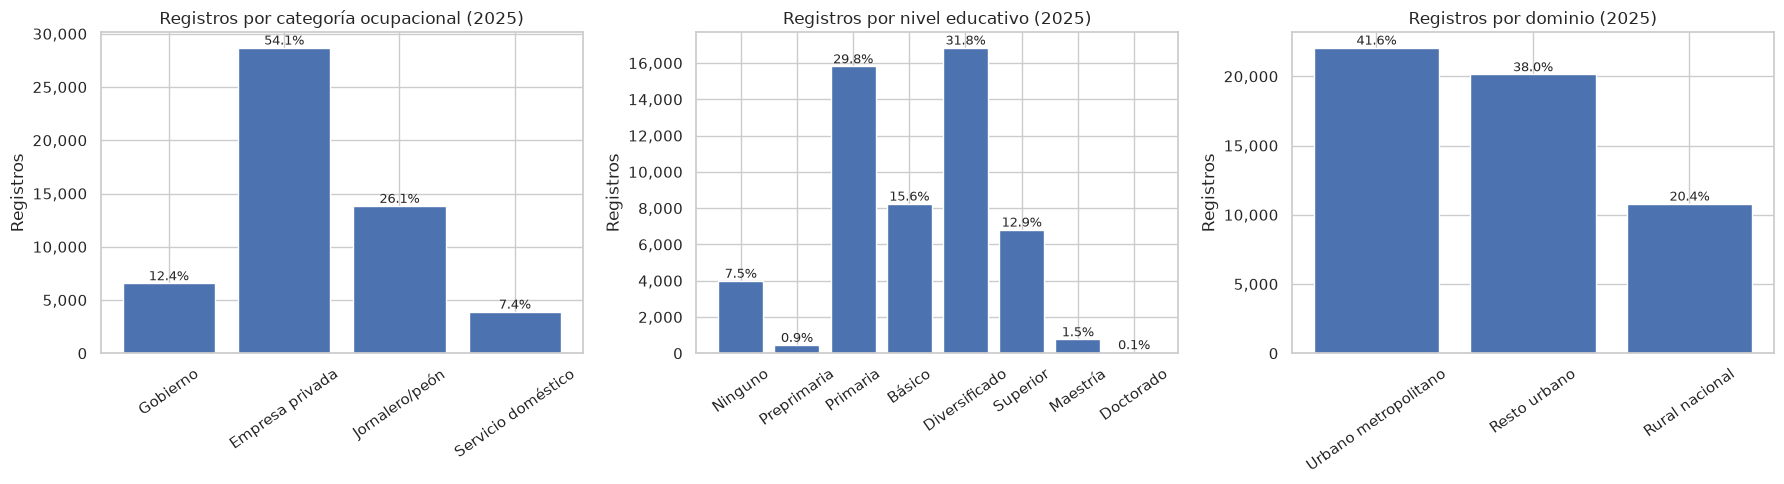

,registros,%
categoria_ocupacional,,
Gobierno,6575.0,12.4
Empresa privada,28702.0,54.1
Jornalero/peón,13842.0,26.1
Servicio doméstico,3906.0,7.4


,registros,%
nivel_educativo,,
Ninguno,3995.0,7.5
Preprimaria,459.0,0.9
Primaria,15822.0,29.8
Básico,8249.0,15.6
Diversificado,16851.0,31.8
Superior,6818.0,12.9
Maestría,771.0,1.5
Doctorado,60.0,0.1


,registros,%
dominio,,
Urbano metropolitano,22072.0,41.6
Resto urbano,20146.0,38.0
Rural nacional,10807.0,20.4


In [19]:
def conteo_cat(df, col, orden):
    pdf = df.groupBy(col).count().toPandas().set_index(col).reindex(orden).dropna()
    pdf["%"] = 100 * pdf["count"] / pdf["count"].sum()
    return pdf

tablas_cat = []
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (col, orden, titulo) in zip(axes, [("categoria_ocupacional", ORDEN_CAT, "Categoría ocupacional"),
                                          ("nivel_educativo", ORDEN_EDU, "Nivel educativo"),
                                          ("dominio", ORDEN_DOM, "Dominio")]):
    pdf = conteo_cat(df25, col, orden)
    bars = ax.bar(pdf.index, pdf["count"], color=sns.color_palette("deep")[0])
    for b, pct in zip(bars, pdf["%"]):
        ax.annotate(f"{pct:.1f}%", (b.get_x() + b.get_width() / 2, b.get_height()), ha="center", va="bottom", fontsize=9)
    ax.set_title(f"Registros por {titulo.lower()} (2025)")
    ax.set_ylabel("Registros"); ax.tick_params(axis="x", rotation=35)
    ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
    tablas_cat.append(pdf.rename(columns={"count": "registros"}).round(1))
plt.tight_layout(); plt.show()
for t in tablas_cat: display(t)

**Interpretación.**
- **Categoría ocupacional:** más de la mitad de los registros (≈54%) son empleados de **empresa privada**; le siguen jornaleros/peones (≈26%), empleados de gobierno (≈12%) y servicio doméstico (≈7%). Los modelos tendrán mucha información sobre el sector privado y relativamente poca sobre servicio doméstico.
- **Nivel educativo:** la muestra se concentra en **diversificado (≈32%)** y **primaria (≈30%)**, seguidos de básico (≈16%) y superior (≈13%). Maestría (771 registros) y sobre todo doctorado (60) son grupos muy pequeños: cualquier estadística o error de predicción en esos grupos será inestable.
- **Dominio:** ≈42% urbano metropolitano, ≈38% resto urbano y ≈20% rural. El peso rural es bajo porque en el área rural predomina el trabajo por cuenta propia y agrícola, que queda fuera de la población asalariada.
- No quedó ningún registro en `DESCONOCIDO` para estas tres variables en la población filtrada.

## 2.2 ¿El salario presenta una distribución simétrica o asimétrica? ¿Qué diferencia existe entre su media y su mediana?

Histograma dibujado con una **muestra aleatoria de 10,000 registros** (sólo para graficar). La media, la mediana y los percentiles marcados provienen del conjunto **completo**.

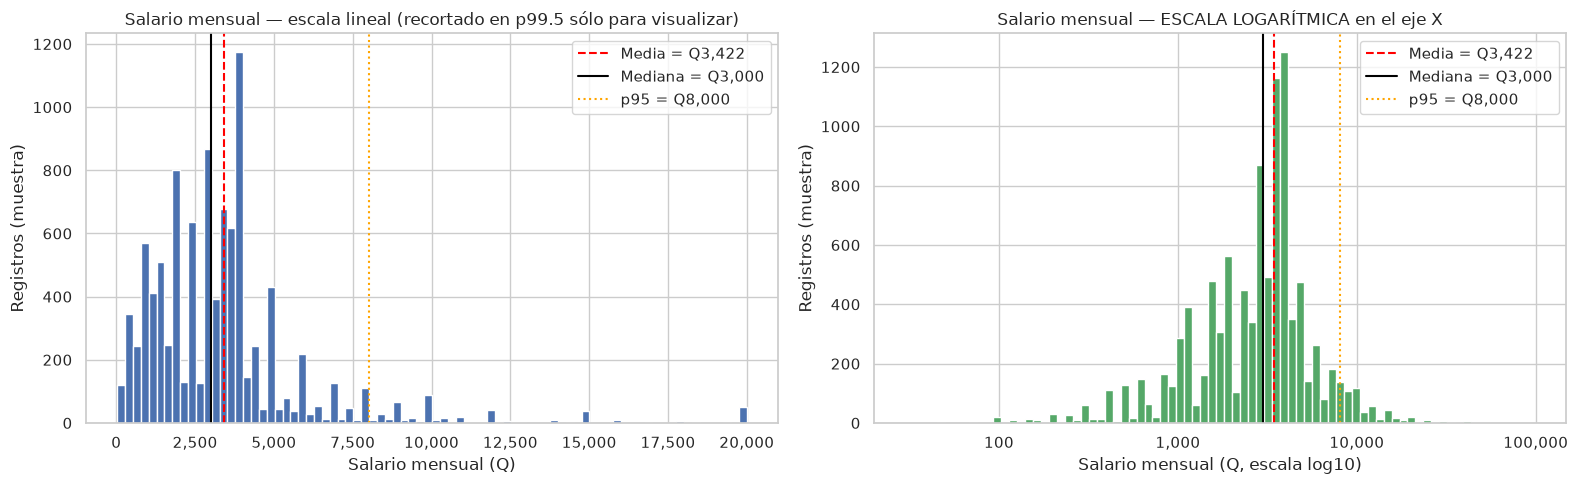

Media - mediana = Q421.68  (14.1% sobre la mediana)
Asimetría (Spark, datos completos) = 6.00


In [20]:
n25 = df25.count()
muestra_sal = (df25.sample(fraction=min(1.0, 12000 / n25), seed=SEED).limit(10000)
               .select("salario_mensual").toPandas())
media_sal, mediana_sal = desc25.loc["Salario mensual (Q)", ["media", "mediana"]]
p95_sal = desc25.loc["Salario mensual (Q)", "p95"]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
ax = axes[0]
ax.hist(muestra_sal["salario_mensual"].clip(upper=muestra_sal["salario_mensual"].quantile(0.995)), bins=80, color="#4C72B0")
ax.set_title("Salario mensual — escala lineal (recortado en p99.5 sólo para visualizar)")
ax.set_xlabel("Salario mensual (Q)")
ax2 = axes[1]
ax2.hist(muestra_sal["salario_mensual"], bins=np.logspace(np.log10(muestra_sal["salario_mensual"].min()),
                                                          np.log10(muestra_sal["salario_mensual"].max()), 80), color="#55A868")
ax2.set_xscale("log")
ax2.set_title("Salario mensual — ESCALA LOGARÍTMICA en el eje X")
ax2.set_xlabel("Salario mensual (Q, escala log10)")
for a in axes:
    a.axvline(media_sal, color="red", ls="--", label=f"Media = Q{media_sal:,.0f}")
    a.axvline(mediana_sal, color="black", ls="-", label=f"Mediana = Q{mediana_sal:,.0f}")
    a.axvline(p95_sal, color="orange", ls=":", label=f"p95 = Q{p95_sal:,.0f}")
    a.set_ylabel("Registros (muestra)"); a.legend()
    a.xaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
plt.tight_layout(); plt.show()

print(f"Media - mediana = Q{media_sal - mediana_sal:,.2f}  ({100 * (media_sal / mediana_sal - 1):.1f}% sobre la mediana)")
print(f"Asimetría (Spark, datos completos) = {desc25.loc['Salario mensual (Q)', 'asimetría']:.2f}")

**Interpretación.** El salario es claramente **asimétrico a la derecha** (asimetría ≈ 6.0 calculada en Spark sobre los 53,025 registros): la mayor parte de los salarios se concentra entre Q1,800 (p25) y Q4,000 (p75), pero hay una cola larga que llega hasta Q99,000 (el p95 es Q8,000, es decir, el 5% superior gana más del doble de la mediana). En escala lineal el histograma es una masa comprimida a la izquierda; en **escala logarítmica** (panel derecho, eje X en log10) la distribución se ve mucho más simétrica, lo que indica una forma aproximadamente log‑normal. También hay salarios anómalamente bajos (desde Q1; 22 registros de 2025 reportan menos de Q100), que se conservan porque cumplen el criterio (>0), pero que probablemente corresponden a pagos parciales o errores de captura.

**Media vs. mediana:** la media (≈ Q3,422) supera a la mediana (Q3,000) en ≈ Q422, un 14% más. La media es arrastrada por los salarios altos de la cola; la **mediana** es una medida más representativa del asalariado “típico”. Esto anticipa que en el modelado los errores cuadráticos (RMSE) estarán muy influidos por pocos salarios extremos. Conforme a las instrucciones, **no** se eliminan ni se transforman los salarios extremos para el modelado; el objetivo se mantiene en quetzales.

## 2.3 ¿Cómo varía el salario mediano entre niveles educativos y categorías ocupacionales?

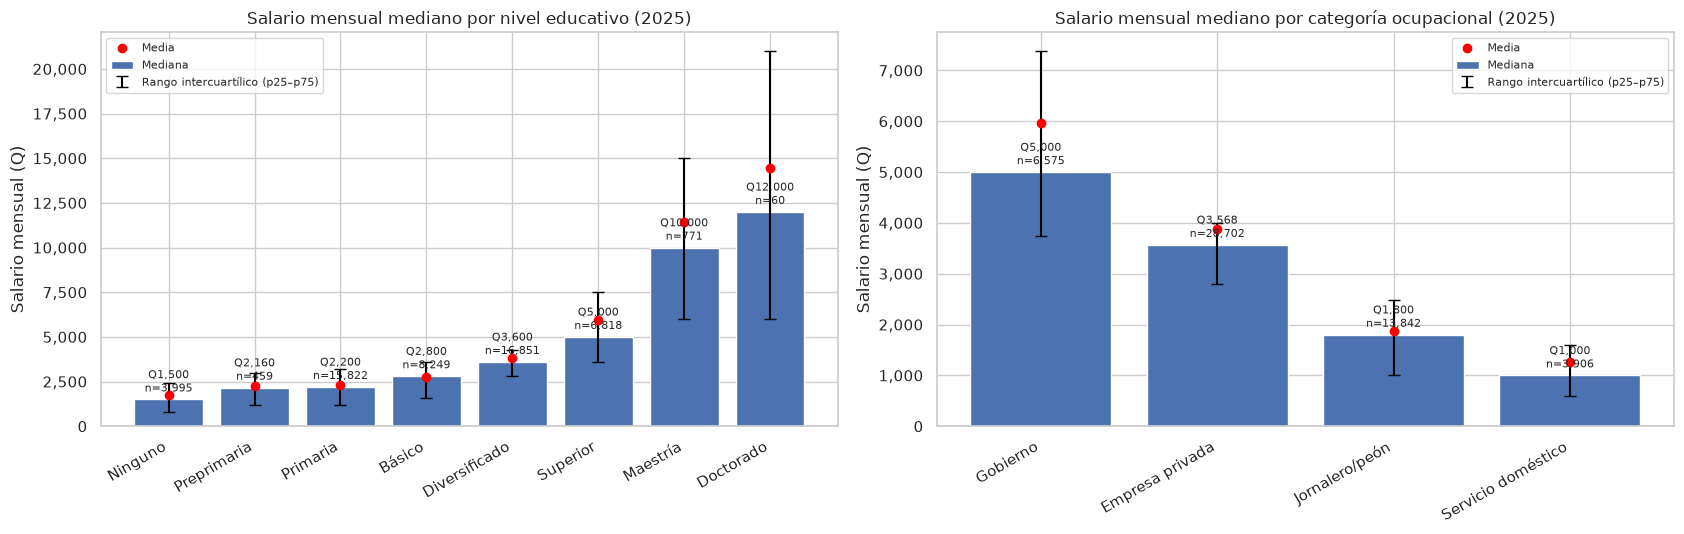

,n,mediana,p25,p75,media
nivel_educativo,,,,,
Ninguno,3995.0,1500.0,800.0,2400.0,1767.1
Preprimaria,459.0,2160.0,1200.0,3000.0,2241.9
Primaria,15822.0,2200.0,1200.0,3200.0,2308.0
Básico,8249.0,2800.0,1600.0,3600.0,2730.2
Diversificado,16851.0,3600.0,2800.0,4250.0,3796.4
Superior,6818.0,5000.0,3600.0,7500.0,5965.3
Maestría,771.0,10000.0,6000.0,15000.0,11409.3
Doctorado,60.0,12000.0,6000.0,21000.0,14452.3


,n,mediana,p25,p75,media
categoria_ocupacional,,,,,
Gobierno,6575.0,5000.0,3750.0,7380.0,5971.5
Empresa privada,28702.0,3567.5,2800.0,4000.0,3875.1
Jornalero/peón,13842.0,1800.0,1000.0,2489.8,1878.6
Servicio doméstico,3906.0,1000.0,600.0,1600.0,1265.7


In [21]:
def mediana_por(df, col, orden):
    pdf = (df.groupBy(col).agg(F.count("*").alias("n"),
                               F.expr("percentile(salario_mensual, 0.5)").alias("mediana"),
                               F.expr("percentile(salario_mensual, 0.25)").alias("p25"),
                               F.expr("percentile(salario_mensual, 0.75)").alias("p75"),
                               F.mean("salario_mensual").alias("media"))
           .toPandas().set_index(col).reindex(orden).dropna())
    return pdf

med_edu = mediana_por(df25, "nivel_educativo", ORDEN_EDU)
med_cat = mediana_por(df25, "categoria_ocupacional", ORDEN_CAT)

fig, axes = plt.subplots(1, 2, figsize=(17, 5.5))
for ax, pdf, titulo in [(axes[0], med_edu, "nivel educativo"), (axes[1], med_cat, "categoría ocupacional")]:
    x = np.arange(len(pdf))
    ax.bar(x, pdf["mediana"], color="#4C72B0", label="Mediana")
    ax.errorbar(x, pdf["mediana"], yerr=[pdf["mediana"] - pdf["p25"], pdf["p75"] - pdf["mediana"]],
                fmt="none", ecolor="black", capsize=4, label="Rango intercuartílico (p25–p75)")
    ax.scatter(x, pdf["media"], color="red", zorder=3, label="Media")
    for xi, (m, n) in enumerate(zip(pdf["mediana"], pdf["n"])):
        ax.annotate(f"Q{m:,.0f}\nn={n:,.0f}", (xi, m), ha="center", va="bottom", fontsize=8, xytext=(0, 3), textcoords="offset points")
    ax.set_xticks(x); ax.set_xticklabels(pdf.index, rotation=30, ha="right")
    ax.set_title(f"Salario mensual mediano por {titulo} (2025)")
    ax.set_ylabel("Salario mensual (Q)"); ax.legend(fontsize=8)
    ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
plt.tight_layout(); plt.show()
display(med_edu.round(1)); display(med_cat.round(1))

**Interpretación.**
- **Educación:** el salario mediano crece de forma casi monótona con el nivel educativo: Q1,500 sin educación, ≈Q2,200 con primaria, Q2,800 con básico, Q3,600 con diversificado, Q5,000 con superior y Q10,000–12,000 con posgrado. El salto más fuerte ocurre a partir del nivel superior, y el rango intercuartílico también se ensancha con la educación (más dispersión salarial en los niveles altos). Maestría y doctorado tienen pocos registros, por lo que su mediana es menos precisa.
- **Categoría ocupacional:** los empleados de **gobierno** tienen la mediana más alta (Q5,000), seguidos de empresa privada (≈Q3,568), jornaleros/peones (Q1,800) y **servicio doméstico** (Q1,000). La brecha entre gobierno y servicio doméstico es de 5 a 1.
- En todas las categorías la media está por encima de la mediana, lo que confirma la asimetría dentro de cada grupo. Estas son **asociaciones**: parte de la diferencia por categoría refleja también diferencias de educación, edad y dominio entre grupos, no un efecto causal.

## 2.4 ¿Cómo cambian el tamaño de la muestra analítica y el salario mediano entre trimestres?

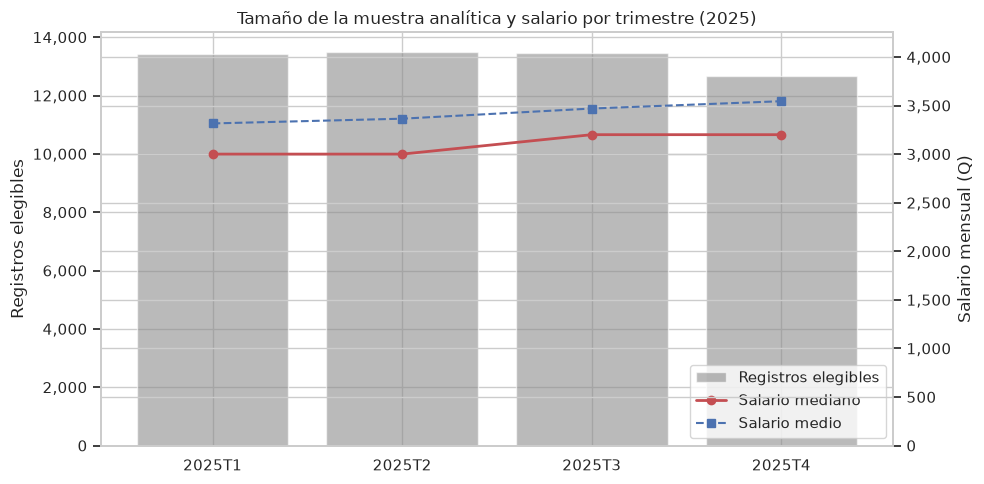

,n,mediana,media,registros originales,% elegible
periodo_archivo,,,,,
2025T1,13419,3000.0,3315.63,51588,26.01
2025T2,13492,3000.0,3364.57,51167,26.37
2025T3,13450,3200.0,3469.07,51583,26.07
2025T4,12664,3200.0,3544.57,49338,25.67


In [22]:
por_trim = (df25.groupBy("periodo_archivo").agg(F.count("*").alias("n"),
                                                F.expr("percentile(salario_mensual, 0.5)").alias("mediana"),
                                                F.mean("salario_mensual").alias("media"))
            .orderBy("periodo_archivo").toPandas().set_index("periodo_archivo"))
por_trim["registros originales"] = tabla.loc["Registros originales", por_trim.index].values
por_trim["% elegible"] = 100 * por_trim["n"] / por_trim["registros originales"]

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.bar(por_trim.index, por_trim["n"], color="#8C8C8C", alpha=0.6, label="Registros elegibles")
ax1.set_ylabel("Registros elegibles"); ax1.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
ax2 = ax1.twinx()
ax2.plot(por_trim.index, por_trim["mediana"], marker="o", color="#C44E52", lw=2, label="Salario mediano")
ax2.plot(por_trim.index, por_trim["media"], marker="s", color="#4C72B0", lw=1.5, ls="--", label="Salario medio")
ax2.set_ylabel("Salario mensual (Q)"); ax2.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
ax2.set_ylim(0, por_trim["media"].max() * 1.2)
h1, l1 = ax1.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="lower right")
plt.title("Tamaño de la muestra analítica y salario por trimestre (2025)")
plt.tight_layout(); plt.show()
por_trim.round(2)

**Interpretación.** El tamaño de la muestra analítica es muy estable entre trimestres (≈13,400 registros en T1–T3 y 12,664 en T4, que también es el archivo con menos registros originales); en todos los casos se conserva ≈26% de los registros originales. El salario mediano pasa de Q3,000 en T1–T2 a Q3,200 en T3–T4 y la media sube gradualmente de ≈Q3,316 a ≈Q3,545: un aumento moderado a lo largo del año, sin cambios bruscos. Esto sugiere que es razonable entrenar con los cuatro trimestres de 2025 y evaluar en 2026T1, aunque una ligera tendencia al alza podría hacer que los modelos subestimen levemente los salarios de 2026. Recordatorio: los mismos hogares pueden aparecer en varios trimestres, por lo que los trimestres no son muestras independientes.